## CS441: Applied ML - HW 2

### Part 1: Model Complexity and Tree-based Regressors

Include all the code for Part 1 in this section

In [ ]:
import numpy as np
from google.colab import drive
%matplotlib inline
from matplotlib import pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# load data (modify to match your data directory or comment)
def load_temp_data():
  drive.mount('/content/drive')
  datadir = "/content/drive/My Drive/CS441/hw1/" 
  T = np.load(datadir + 'temperature_data.npz')
  x_train, y_train, x_val, y_val, x_test, y_test, dates_train, dates_val, dates_test, feature_to_city, feature_to_day = \
  T['x_train'], T['y_train'], T['x_val'], T['y_val'], T['x_test'], T['y_test'], T['dates_train'], T['dates_val'], T['dates_test'], T['feature_to_city'], T['feature_to_day']
  return (x_train, y_train, x_val, y_val, x_test, y_test, dates_train, dates_val, dates_test, feature_to_city, feature_to_day)

# plot one data point for listed cities and target temperature
def plot_temps(x, y, cities, feature_to_city, feature_to_day, target_date):
  nc = len(cities)
  ndays = 5
  xplot = np.array([-5,-4,-3,-2,-1])
  yplot = np.zeros((nc,ndays))
  for f in np.arange(len(x)):
    for c in np.arange(nc):
      if cities[c]==feature_to_city[f]:
        yplot[feature_to_day[f]+ndays,c] = x[f]
  plt.plot(xplot,yplot)
  plt.legend(cities)
  plt.plot(0, y, 'b*', markersize=10)
  plt.title('Predict Temp for Cleveland on ' + target_date)
  plt.xlabel('Day')
  plt.ylabel('Avg Temp (C)')
  plt.show()

# load data
(x_train, y_train, x_val, y_val, x_test, y_test, dates_train, dates_val, dates_test, feature_to_city, feature_to_day) = load_temp_data()

In [ ]:
# to plot the errors
def plot_depth_error(max_depths, tree_train_err, tree_val_err, rf_train_err, rf_val_err, bt_train_err, bt_val_err):
  plt.figure(figsize=(15,15))
  plt.semilogx(max_depths, tree_train_err, 'r.--',label='tree train')
  plt.semilogx(max_depths, tree_val_err, 'r.-', label='tree val')
  plt.semilogx(max_depths, rf_train_err, 'g.--',label='RF train')
  plt.semilogx(max_depths, rf_val_err, 'g.-', label='RF val')
  plt.semilogx(max_depths, bt_train_err, 'b.--',label='BT train')
  plt.semilogx(max_depths, bt_val_err, 'b.-', label='BT val')
  plt.ylabel('RMSE Error')
  plt.xlabel('Max Tree Depth')
  plt.xticks(max_depths, max_depths)
  plt.legend()
  plt.rcParams.update({'font.size': 20})
  plt.show()

In [ ]:
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

max_depths = [2,4,8,16,32]

# usage examples
# DTR = DecisionTreeRegressor(random_state=0, max_depth=max_depths)
# RFR = RandomForestRegressor(random_state=0, max_depth=max_depths, max_features=1/3)
# GBR = GradientBoostingRegressor(random_state=0, max_depth=max_depths)

In [ ]:
# Creating six arrays to hold the train and val RMSE values. 
DTRTRMSE = []
RFRTRMSE = []
GBRTRMSE = []
DTRVRMSE = []
RFRVRMSE = []
GBRVRMSE = []

In [ ]:
# Getting the train RMSE value for DecisionTreeRegressor when the max depth value is 2.
DTRMT1 = DecisionTreeRegressor(random_state=0, max_depth=2)
DTRMT1.fit(x_train, y_train)
DTRMT1P = DTRMT1.predict(x_train)
DTRTRMSE.append(np.sqrt(np.mean((DTRMT1P-y_train)**2)))

In [ ]:
# Getting the val RMSE value for DecisionTreeRegressor when the max depth value is 4.
DTRMV1 = DecisionTreeRegressor(random_state=0, max_depth=2)
DTRMV1.fit(x_train, y_train)
DTRMV1P = DTRMV1.predict(x_val)
DTRVRMSE.append(np.sqrt(np.mean((DTRMV1P-y_val)**2)))

In [ ]:
# Getting the train RMSE value for DecisionTreeRegressor when the max depth value is 4.
DTRMT2 = DecisionTreeRegressor(random_state=0, max_depth=4)
DTRMT2.fit(x_train, y_train)
DTRMT2P = DTRMT2.predict(x_train)
DTRTRMSE.append(np.sqrt(np.mean((DTRMT2P-y_train)**2)))

In [ ]:
# Getting the val RMSE value for DecisionTreeRegressor when the max depth value is 4.
DTRMV2 = DecisionTreeRegressor(random_state=0, max_depth=4)
DTRMV2.fit(x_train, y_train)
DTRMV2P = DTRMV2.predict(x_val)
DTRVRMSE.append(np.sqrt(np.mean((DTRMV2P-y_val)**2)))

In [ ]:
# Getting the train RMSE value for DecisionTreeRegressor when the max depth value is 8.
DTRMT3 = DecisionTreeRegressor(random_state=0, max_depth=8)
DTRMT3.fit(x_train, y_train)
DTRMT3P = DTRMT3.predict(x_train)
DTRTRMSE.append(np.sqrt(np.mean((DTRMT3P-y_train)**2)))

In [ ]:
# Getting the val RMSE value for DecisionTreeRegressor when the max depth value is 8.
DTRMV3 = DecisionTreeRegressor(random_state=0, max_depth=8)
DTRMV3.fit(x_train, y_train)
DTRMV3P = DTRMV3.predict(x_val)
DTRVRMSE.append(np.sqrt(np.mean((DTRMV3P-y_val)**2)))

In [ ]:
# Getting the train RMSE value for DecisionTreeRegressor when the max depth value is 16.
DTRMT4 = DecisionTreeRegressor(random_state=0, max_depth=16)
DTRMT4.fit(x_train, y_train)
DTRMT4P = DTRMT4.predict(x_train)
DTRTRMSE.append(np.sqrt(np.mean((DTRMT4P-y_train)**2)))

In [ ]:
# Getting the val RMSE value for DecisionTreeRegressor when the max depth value is 16.
DTRMV4 = DecisionTreeRegressor(random_state=0, max_depth=16)
DTRMV4.fit(x_train, y_train)
DTRMV4P = DTRMT4.predict(x_val)
DTRVRMSE.append(np.sqrt(np.mean((DTRMV4P-y_val)**2)))

In [ ]:
# Getting the train RMSE value for DecisionTreeRegressor when the max depth value is 32.
DTRMT5 = DecisionTreeRegressor(random_state=0, max_depth=32)
DTRMT5.fit(x_train, y_train)
DTRMT5P = DTRMT5.predict(x_train)
DTRTRMSE.append(np.sqrt(np.mean((DTRMT5P-y_train)**2)))

In [ ]:
# Getting the val RMSE value for DecisionTreeRegressor when the max depth value is 32.
DTRMV5 = DecisionTreeRegressor(random_state=0, max_depth=32)
DTRMV5.fit(x_train, y_train)
DTRMV5P = DTRMV5.predict(x_val)
DTRVRMSE.append(np.sqrt(np.mean((DTRMV5P-y_val)**2)))

In [ ]:
# Getting the train RMSE value for RandomForestRegressor when the max depth value is 2.
RFRMT1 = RandomForestRegressor(random_state=0, max_depth=2, max_features=1/3)
RFRMT1.fit(x_train, y_train)
RFRMT1P = RFRMT1.predict(x_train)
RFRTRMSE.append(np.sqrt(np.mean((RFRMT1P-y_train)**2)))

In [ ]:
# Getting the train RMSE value for RandomForestRegressor when the max depth value is 4.
RFRMT2 = RandomForestRegressor(random_state=0, max_depth=4, max_features=1/3)
RFRMT2.fit(x_train, y_train)
RFRMT2P = RFRMT2.predict(x_train)
RFRTRMSE.append(np.sqrt(np.mean((RFRMT2P-y_train)**2)))

In [ ]:
# Getting the train RMSE value for RandomForestRegressor when the max depth value is 8.
RFRMT3 = RandomForestRegressor(random_state=0, max_depth=8, max_features=1/3)
RFRMT3.fit(x_train, y_train)
RFRMT3P = RFRMT3.predict(x_train)
RFRTRMSE.append(np.sqrt(np.mean((RFRMT3P-y_train)**2)))

In [ ]:
# Getting the train RMSE value for RandomForestRegressor when the max depth value is 16.
RFRMT4 = RandomForestRegressor(random_state=0, max_depth=16, max_features=1/3)
RFRMT4.fit(x_train, y_train)
RFRMT4P = RFRMT4.predict(x_train)
RFRTRMSE.append(np.sqrt(np.mean((RFRMT4P-y_train)**2)))

In [ ]:
# Getting the train RMSE value for RandomForestRegressor when the max depth value is 32.
RFRMT5 = RandomForestRegressor(random_state=0, max_depth=32, max_features=1/3)
RFRMT5.fit(x_train, y_train)
RFRMT5P = RFRMT5.predict(x_train)
RFRTRMSE.append(np.sqrt(np.mean((RFRMT5P-y_train)**2)))

In [ ]:
# Getting the val RMSE value for RandomForestRegressor when the max depth value is 2.
RFRMV1 = RandomForestRegressor(random_state=0, max_depth=2, max_features=1/3)
RFRMV1.fit(x_train, y_train)
RFRMV1P = RFRMT1.predict(x_val)
RFRVRMSE.append(np.sqrt(np.mean((RFRMV1P-y_val)**2)))

In [ ]:
# Getting the val RMSE value for RandomForestRegressor when the max depth value is 4.
RFRMV2 = RandomForestRegressor(random_state=0, max_depth=4, max_features=1/3)
RFRMV2.fit(x_train, y_train)
RFRMV2P = RFRMT2.predict(x_val)
RFRVRMSE.append(np.sqrt(np.mean((RFRMV2P-y_val)**2)))

In [ ]:
# Getting the val RMSE value for RandomForestRegressor when the max depth value is 8.
RFRMV3 = RandomForestRegressor(random_state=0, max_depth=8, max_features=1/3)
RFRMV3.fit(x_train, y_train)
RFRMV3P = RFRMT3.predict(x_val)
RFRVRMSE.append(np.sqrt(np.mean((RFRMV3P-y_val)**2)))

In [ ]:
# Getting the val RMSE value for RandomForestRegressor when the max depth value is 16.
RFRMV4 = RandomForestRegressor(random_state=0, max_depth=16, max_features=1/3)
RFRMV4.fit(x_train, y_train)
RFRMV4P = RFRMT4.predict(x_val)
RFRVRMSE.append(np.sqrt(np.mean((RFRMV4P-y_val)**2)))

In [ ]:
# Getting the val RMSE value for RandomForestRegressor when the max depth value is 32.
RFRMV5 = RandomForestRegressor(random_state=0, max_depth=32, max_features=1/3)
RFRMV5.fit(x_train, y_train)
RFRMV5P = RFRMT5.predict(x_val)
RFRVRMSE.append(np.sqrt(np.mean((RFRMV5P-y_val)**2)))

In [ ]:
# Getting the train RMSE value for GradientBoostingRegressor when the max depth value is 2.
GBRMT1 = GradientBoostingRegressor(random_state=0, max_depth=2)
GBRMT1.fit(x_train, y_train)
GBRMT1P = GBRMT1.predict(x_train)
GBRTRMSE.append(np.sqrt(np.mean((GBRMT1P-y_train)**2)))

In [ ]:
# Getting the train RMSE value for GradientBoostingRegressor when the max depth value is 4.
GBRMT2 = GradientBoostingRegressor(random_state=0, max_depth=4)
GBRMT2.fit(x_train, y_train)
GBRMT2P = GBRMT2.predict(x_train)
GBRTRMSE.append(np.sqrt(np.mean((GBRMT2P-y_train)**2)))

In [ ]:
# Getting the train RMSE value for GradientBoostingRegressor when the max depth value is 8.
GBRMT3 = GradientBoostingRegressor(random_state=0, max_depth=8)
GBRMT3.fit(x_train, y_train)
GBRMT3P = GBRMT3.predict(x_train)
GBRTRMSE.append(np.sqrt(np.mean((GBRMT3P-y_train)**2)))

In [ ]:
# Getting the train RMSE value for GradientBoostingRegressor when the max depth value is 16.
GBRMT4 = GradientBoostingRegressor(random_state=0, max_depth=16)
GBRMT4.fit(x_train, y_train)
GBRMT4P = GBRMT4.predict(x_train)
GBRTRMSE.append(np.sqrt(np.mean((GBRMT4P-y_train)**2)))

In [ ]:
# Getting the train RMSE value for GradientBoostingRegressor when the max depth value is 32.
GBRMT5 = GradientBoostingRegressor(random_state=0, max_depth=32)
GBRMT5.fit(x_train, y_train)
GBRMT5P = GBRMT5.predict(x_train)
GBRTRMSE.append(np.sqrt(np.mean((GBRMT5P-y_train)**2)))

In [ ]:
# Getting the val RMSE value for GradientBoostingRegressor when the max depth value is 2.
GBRMV1 = GradientBoostingRegressor(random_state=0, max_depth=2)
GBRMV1.fit(x_train, y_train)
GBRMV1P = GBRMV1.predict(x_val)
GBRVRMSE.append(np.sqrt(np.mean((GBRMV1P-y_val)**2)))

In [ ]:
# Getting the val RMSE value for GradientBoostingRegressor when the max depth value is 4.
GBRMV2 = GradientBoostingRegressor(random_state=0, max_depth=4)
GBRMV2.fit(x_train, y_train)
GBRMV2P = GBRMV2.predict(x_val)
GBRVRMSE.append(np.sqrt(np.mean((GBRMV2P-y_val)**2)))

In [ ]:
# Getting the val RMSE value for GradientBoostingRegressor when the max depth value is 8.
GBRMV3 = GradientBoostingRegressor(random_state=0, max_depth=8)
GBRMV3.fit(x_train, y_train)
GBRMV3P = GBRMV3.predict(x_val)
GBRVRMSE.append(np.sqrt(np.mean((GBRMV3P-y_val)**2)))

In [ ]:
# Getting the val RMSE value for GradientBoostingRegressor when the max depth value is 16.
GBRMV4 = GradientBoostingRegressor(random_state=0, max_depth=16)
GBRMV4.fit(x_train, y_train)
GBRMV4P = GBRMV4.predict(x_val)
GBRVRMSE.append(np.sqrt(np.mean((GBRMV4P-y_val)**2)))

In [ ]:
# Getting the val RMSE value for GradientBoostingRegressor when the max depth value is 32.
GBRMV5 = GradientBoostingRegressor(random_state=0, max_depth=32)
GBRMV5.fit(x_train, y_train)
GBRMV5P = GBRMV5.predict(x_val)
GBRVRMSE.append(np.sqrt(np.mean((GBRMV5P-y_val)**2)))

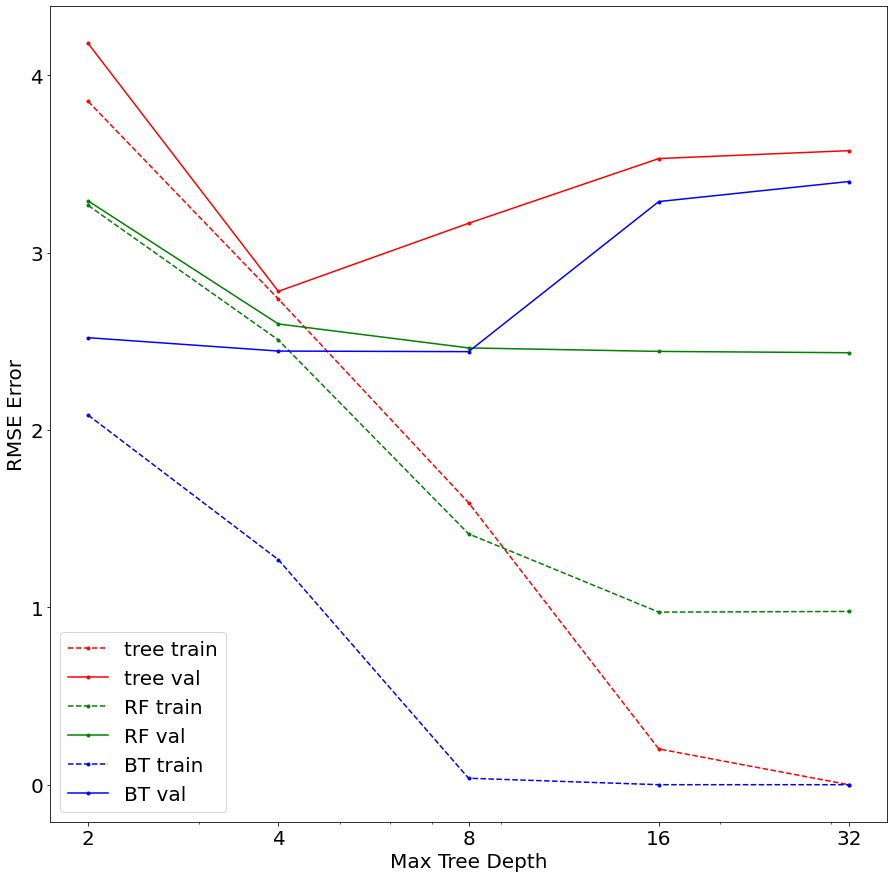

In [ ]:
# Plotting the depth error chart by calling the plot_depth_error function.
PDE = plot_depth_error(max_depths, DTRTRMSE, DTRVRMSE, RFRTRMSE, RFRVRMSE, GBRTRMSE, GBRVRMSE)

### Part 2: MLPs with MNIST

Include all the code for Part 2 in this section

In [2]:
# initialization code
import numpy as np
from keras.datasets import mnist
%matplotlib inline
from matplotlib import pyplot as plt
from scipy import stats
import torch
import torch.nn as nn

# loads MNIST data and reformat to 768-d vectors with values in range 0 to 1
# splits into train/val/test sets and provides indices for subsets of train
def load_mnist():
  (x_train, y_train), (x_test, y_test) = mnist.load_data()
  x_train = np.reshape(x_train, (len(x_train), 28*28))
  x_test = np.reshape(x_test, (len(x_test), 28*28))
  maxval = x_train.max()
  x_train = x_train/maxval
  x_test = x_test/maxval
  x_val = x_train[:10000]
  y_val = y_train[:10000]
  x_train = x_train[10000:]
  y_train = y_train[10000:]
  train_indices = dict()
  train_indices['xs'] = np.arange(50)
  train_indices['s'] = np.arange(500)
  train_indices['m'] = np.arange(5000)
  train_indices['all'] = np.arange(50000)
  return (x_train, y_train), (x_val, y_val), (x_test, y_test), train_indices

# displays a set of mnist images
def display_mnist(x, subplot_rows=1, subplot_cols=1):
  if subplot_rows>1 or subplot_cols>1:
    fig, ax = plt.subplots(subplot_rows, subplot_cols, figsize=(15,15))
    for i in np.arange(len(x)):
      ax[i].imshow(np.reshape(x[i], (28,28)), cmap='gray')
      ax[i].axis('off')
  else:
      plt.imshow(np.reshape(x, (28,28)), cmap='gray')
      plt.axis('off')
  plt.show()

# counts the number of examples per class
def class_count_mnist(y):
  count = np.zeros((10,),dtype='uint32')
  for i in np.arange(10):
    count[i] = sum(y==i)
  return count

In [ ]:
(x_train, y_train), (x_val, y_val), (x_test, y_test), train_indices = load_mnist()

In [ ]:
# Sets device to "cuda" if a GPU is available  (in Colabs, enable GPU by Edit->Notebook Settings-->Hardware Accelerator=GPU)
device = "cuda" if torch.cuda.is_available() else 'cpu'

In [ ]:
def display_error_curves(num_epochs, training_losses, validation_losses):
  """
  Plots the training and validation loss curves
  """

  plt.plot(range(num_epochs), training_losses, label="Training Loss")
  plt.plot(range(num_epochs), validation_losses, label="Validation Loss")

  # Add in a title and axes labels
  plt.title('Training and Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  
  # Display the plot
  plt.legend(loc='best')
  plt.show()

In [ ]:
# Creating a training set.
trainset = torch.utils.data.TensorDataset(torch.Tensor(x_train), torch.Tensor(np.eye(10)[y_train]))

# Creating a training loader.
train_loader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, num_workers=1)

# Creating a validation set.
valset = torch.utils.data.TensorDataset(torch.Tensor(x_val), torch.Tensor(np.eye(10)[y_val]))

# Creating a validation loader.
val_loader = torch.utils.data.DataLoader(valset, batch_size=256, shuffle=False, num_workers=1)

In [ ]:
# Defining a model called MLP.
class MLP(nn.Module):
    # Creating a function called __init__.
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()

        # Creating variables called linearOne, reluOne, and linearTwo..
        self.linearOne = nn.Linear(input_size, hidden_size) 

        self.reluOne = nn.ReLU()
        
        self.linearTwo = nn.Linear(hidden_size, output_size)  
    
    # Creating a function called forward.
    def forward(self, x1):
      
        # Setting x2 equal to linearOne, reluOne, and linearTwo.
        x2 = self.linearOne(x1)
        x2 = self.reluOne(x2)
        x2 = self.linearTwo(x2)

        return x2 # Returning x2.

In [ ]:
# Creating a function called train_MLP_mnist.
def train_MLP_mnist(train_loader, val_loader, lr=0.12, num_epochs=100):
  '''
  Train a MLP 
  Input: X[i] is the ith training data. y[i] is the ith training label. alpha is the count prior
  Output: return a trained MLP
  '''
  # Declaring input_size, hidden_size, and output_size.
  input_size = 784
  hidden_size = 64
  output_size = 10

  # Instantiating the model.
  mlp = MLP(input_size, hidden_size, output_size).to(device)

  # Setting optimizer and loss function
  optimizer = torch.optim.SGD(mlp.parameters(), lr) 
  loss_function = nn.CrossEntropyLoss()

  # Creating the train_loss and val_loss arrays.
  train_loss = []
  val_loss = []

  # Training the model.
  for epoch in range(0, num_epochs):    

    # Creating the t_loss and v_loss variables.
    t_loss = 0.0
    v_loss = 0.0

    # Iterating over the DataLoader for training data.
    for i, data in enumerate(train_loader, 0): 

      inputs, targets = data # Getting inputs.

      inputs = inputs.to(device) # Sending inputs to device.

      targets = targets.to(device) # Sending targets to device.

      optimizer.zero_grad() # Zeroing the gradients.

      outputs = mlp(inputs) # Computing logit scores for current batch.

      loss = loss_function(outputs, targets) # Computing loss.

      loss.backward() # Here is the backprop loss.

      optimizer.step() # Updating weights.

      t_loss += loss.item() # Adding loss to t_loss.

    # Iterating over the DataLoader for validation data.
    for i, data in enumerate(val_loader, 0): 

      inputs, targets = data # Get inputs

      inputs = inputs.to(device) # Sending inputs to device.

      targets = targets.to(device) # Sending targets to device.

      outputs = mlp(inputs) # Computing logit scores for current batch.

      loss = loss_function(outputs, targets) # Computing loss.

      v_loss += loss.item() # Adding loss to v_loss.
 
    train_loss.append(t_loss/i) # Appending to the train_loss array.

    val_loss.append(v_loss/i) # Appending to the val_loss array.

  # Printing the loss information for the training loader.
  print("The train array is: ", train_loss)
  print("The 25 epoch is: ", train_loss[24])
  print("The 50 epoch is: ", train_loss[49])
  print("The 100 epoch is: ", train_loss[99])

  # Printing the loss information for the validation loader.
  print("The val array is: ", val_loss)
  print("The 25 epoch is: ", val_loss[24])
  print("The 50 epoch is: ", val_loss[49])
  print("The 100 epoch is: ", val_loss[99])

  # Here the loss curves are displayed.
  display_error_curves(num_epochs, train_loss, val_loss)
  
  # Here mlp is returned.
  return mlp

The train array is:  [4.128838999913289, 1.8139234150831516, 1.5544168253739674, 1.3997352975301254, 1.2772936450365262, 1.1732819886543813, 1.079968047256653, 1.0059867791640453, 0.9337924451400073, 0.8777413440820498, 0.8233472357193629, 0.7744709860820037, 0.735741295111485, 0.7004613414024695, 0.6620573624968529, 0.6303291644614476, 0.6057591566290611, 0.5798263549804688, 0.5550652963515276, 0.5328154435906655, 0.5130987548484252, 0.4976553485179559, 0.4776896055883322, 0.46100381943277824, 0.4462321714904064, 0.43171447448623484, 0.4220015931014831, 0.40621206785241765, 0.39458894691406154, 0.3812460298052965, 0.37166380547942257, 0.3600734474662787, 0.3511866109493451, 0.3418665959093815, 0.33161029090675026, 0.3239766070380425, 0.3163411024098213, 0.3080695299192881, 0.3012456159847669, 0.2939722499786279, 0.28647803634596175, 0.2814942895410917, 0.2739412329899959, 0.2670393631530878, 0.26051939035264343, 0.2552719770047145, 0.2487141240435915, 0.24416702293241635, 0.2393892422

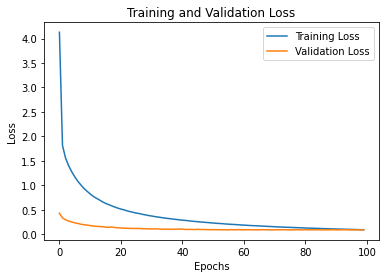

MLP(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
# Here is the information when the learning rate is improved to 0.12.
train_MLP_mnist(train_loader, val_loader)

The train array is:  [11.493755695147392, 11.32093959588271, 11.123846145776602, 10.902184437482784, 10.657751456285135, 10.396938189482077, 10.119756233997833, 9.829551201600294, 9.52686221171648, 9.213102783912268, 8.891701414034916, 8.566193219942924, 8.23843029829172, 7.915422247006343, 7.598755518595378, 7.293669682282668, 6.999344128828782, 6.720296202561794, 6.45443558998597, 6.205851114713228, 5.9712440723027935, 5.752034370715801, 5.547598245816353, 5.3589511926357565, 5.1837843121626435, 5.018343000839918, 4.863560271568788, 4.720752060413361, 4.586728713451287, 4.463350195151109, 4.349940272477957, 4.238182162627195, 4.135246359384977, 4.0411517558953705, 3.952113547386267, 3.8674826270494704, 3.789031215203114, 3.713846200551742, 3.64417172395266, 3.573762219685775, 3.5110631569837913, 3.4486778454902844, 3.3922256292440953, 3.337675045698117, 3.288431989840972, 3.2407993964659862, 3.1911642597271848, 3.1490252369489427, 3.1032341099702396, 3.063143742390168, 3.024372244492

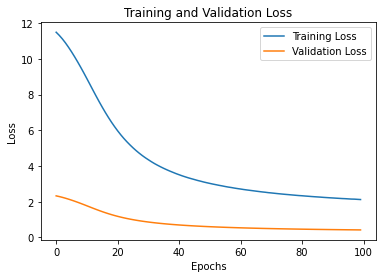

MLP(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
# Here is the information when the learning rate is 0.001.
train_MLP_mnist(train_loader, val_loader)

The train array is:  [10.548699513459818, 7.824162107247573, 5.374181501376323, 4.0182264890426245, 3.3042000379317846, 2.886425386636685, 2.6157207802320137, 2.425707538922628, 2.286858250697454, 2.1837128095137768, 2.0941022909604587, 2.0301587742108564, 1.964142273633908, 1.916142700574337, 1.869844342271487, 1.8326582923913612, 1.8000990007168207, 1.7706078986326854, 1.7418390802848034, 1.7175228740924444, 1.694668166912519, 1.672316510707904, 1.6504966956682694, 1.6325246202640045, 1.6127056941772118, 1.5935796407552867, 1.5771001027180598, 1.56413773389963, 1.5481235980987549, 1.5300532820133061, 1.5157681237428615, 1.500088734504504, 1.49068578122518, 1.4733646771846673, 1.4631313803868415, 1.4478246539067, 1.435918887456258, 1.4263674200345309, 1.4098840126624475, 1.3995423282568271, 1.3869955933246858, 1.3748761782279382, 1.3696628721096578, 1.3561583413527563, 1.344925507521018, 1.3393762914034038, 1.3216088024469523, 1.313160864970623, 1.3025833742740827, 1.2934683106648617,

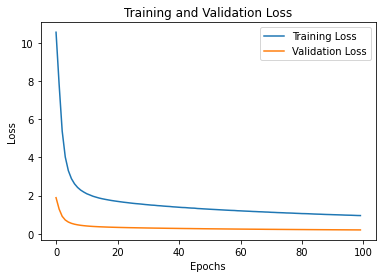

MLP(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
# Here is the information when the learning rate is 0.01.
train_MLP_mnist(train_loader, val_loader)

The train array is:  [4.569005897411933, 1.8987049811925643, 1.6298479369053473, 1.48836133762812, 1.3757569446013524, 1.2785164476969304, 1.1959863201929972, 1.1233298631432729, 1.0619181606632013, 1.0066120496545083, 0.9533896620074908, 0.9054663420105592, 0.8606439548043104, 0.8223074645950244, 0.7894581663302886, 0.7550005899407924, 0.7225591914776044, 0.697321067062708, 0.6696730552193446, 0.6450833296164488, 0.6220082134390489, 0.6015600013809327, 0.5795837977948861, 0.5607064792361015, 0.5433568798769743, 0.5265906156064608, 0.5110460832141913, 0.49618659894435835, 0.4805774523470646, 0.46536742848081464, 0.4557899543299125, 0.4429744269985419, 0.4304479450369493, 0.41975350238573855, 0.4075712586920231, 0.39719189006166583, 0.38775036302514565, 0.3785046456047358, 0.36817958034001863, 0.35905520603633845, 0.3540790367584962, 0.34266164153814316, 0.33474102234229064, 0.3277239788992283, 0.3227055706561376, 0.31289076532881993, 0.30720326863229275, 0.30027835443615913, 0.29375791

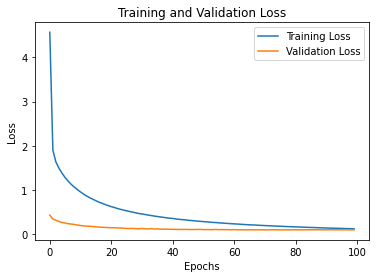

MLP(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
# Here is the information when the learning rate is 0.1.
train_MLP_mnist(train_loader, val_loader)

The train array is:  [2.5617285076624308, 0.9814620428742507, 0.7452133658986825, 0.6236843288135834, 0.5289659693073003, 0.4633803519491966, 0.42551098372309637, 0.40477639362693596, 0.34570236016924566, 0.3166729057542024, 0.29033264278983456, 0.2670008572630393, 0.248916361361551, 0.2272386325714298, 0.21183344611945826, 0.18991569166955274, 0.18713583150066626, 0.16660969391560707, 0.15174892673698756, 0.14470934299513316, 0.1308883457349088, 0.11979283331535183, 0.10696734999043819, 0.10363283261465721, 0.09593827351450156, 0.08780452087879755, 0.07843934311173283, 0.0711246572721463, 0.06577780195034276, 0.056615643734589986, 0.05564709574891589, 0.050751017627473444, 0.04685147728723211, 0.042100989271719486, 0.04061077365603966, 0.036996028797987565, 0.03254441930076633, 0.027790430407875624, 0.026794793284259353, 0.02496891726966565, 0.023579497929089345, 0.02101160176934149, 0.019705769973090634, 0.01794034180840334, 0.01701948804876361, 0.016571608369047634, 0.01536712868927

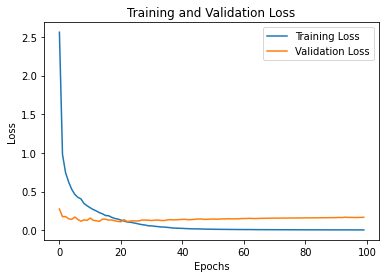

MLP(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
# Here is the information when the learning rate is 1.
train_MLP_mnist(train_loader, val_loader)

In [ ]:
# experiments code
print(device) # make sure you're using GPU instance
torch.manual_seed(0) # to avoid randomness, but if you wanted to create an ensemble, you should not use a manual seed

cuda


## Part 3: Predicting Penguin Species

Include all your code for part 3 in this section.  

In [ ]:
import numpy as np
from google.colab import drive
%matplotlib inline
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
#styling preferences for sns
sns.set_style('whitegrid')
sns.set_context('poster')
drive.mount('/content/gdrive/')
datadir = "/content/gdrive/MyDrive/CS441/hw2/" 
df_penguins = pd.read_csv(datadir + 'penguins_size.csv')
df_penguins.head(10)

def get_penguin_xy(df_penguins):
  data = np.array(df_penguins[['island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']])
  y = df_penguins['species']
  ui = np.unique(data[:,0])
  us = np.unique(data[:,-1])
  X = np.zeros((len(y), 10))
  for i in range(len(y)):
    f = 0
    for j in range(len(ui)):
      if data[i, f]==ui[j]:
        X[i, f+j] = 1
    X[i, 3:7] = data[i, 1:5]
    for j in range(len(us)):
      if data[i, 5]==us[j]:
        X[i, f+j] = 1
  feature_names = ['island_biscoe', 'island_dream', 'island_torgersen', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex_female', 'sex_male', 'sex_unknown']
  X = pd.DataFrame(X, columns=feature_names)
  return(X, y, feature_names, np.unique(y))


Mounted at /content/gdrive/


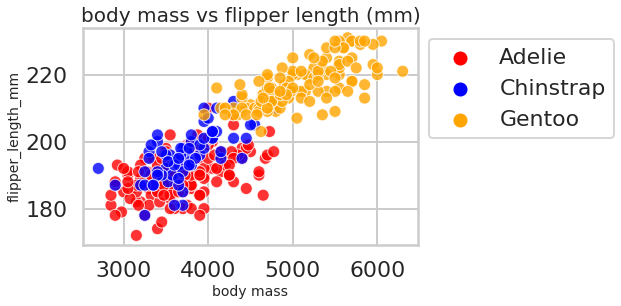

In [ ]:
palette = ["red", "blue", "orange"]

# https://seaborn.pydata.org/generated/seaborn.scatterplot.html
sns.scatterplot(data=df_penguins, x = 'body_mass_g', y = 'flipper_length_mm', 
               hue = 'species', palette=palette, alpha=0.8)

plt.xlabel('body mass', fontsize=14)
plt.ylabel('flipper_length_mm', fontsize=14)
plt.title('body mass vs flipper length (mm)', fontsize=20)
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.show()

# create other visualizations

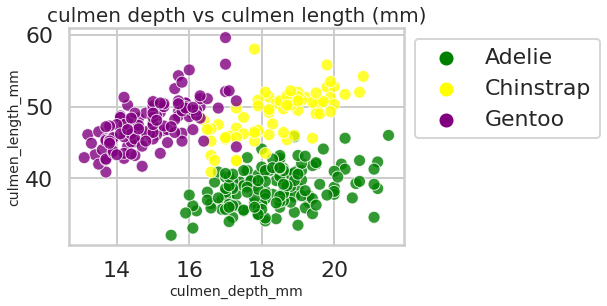

In [ ]:
# Creating a palette with three different colors.
palette = ["green", "yellow", "purple"]

# Letting the scatterplot know about the features that it will be using.
sns.scatterplot(data=df_penguins, x = 'culmen_depth_mm', y = 'culmen_length_mm', 
               hue = 'species', palette=palette, alpha=0.8)

# Plotting the actual scatterplot.
plt.xlabel('culmen_depth_mm', fontsize=14)
plt.ylabel('culmen_length_mm', fontsize=14)
plt.title('culmen depth vs culmen length (mm)', fontsize=20)
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.show()

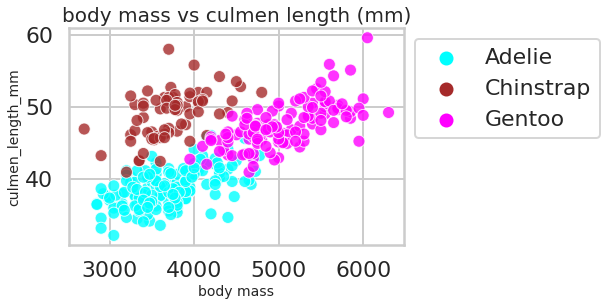

In [ ]:
# Creating a palette with three different colors.
palette = ["cyan", "brown", "magenta"]

# Letting the scatterplot know about the features that it will be using.
sns.scatterplot(data=df_penguins, x = 'body_mass_g', y = 'culmen_length_mm', 
               hue = 'species', palette=palette, alpha=0.8)

# Plotting the actual scatterplot.
plt.xlabel('body mass', fontsize=14)
plt.ylabel('culmen_length_mm', fontsize=14)
plt.title('body mass vs culmen length (mm)', fontsize=20)
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.show()

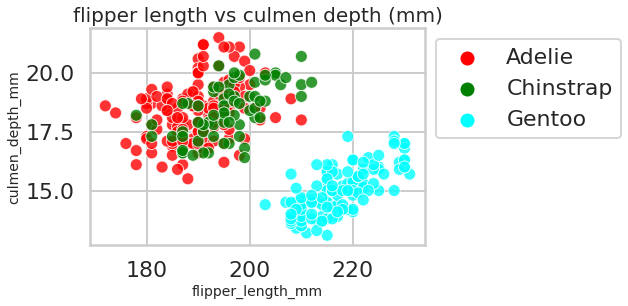

In [ ]:
# Creating a palette with three different colors.
palette = ["red", "green", "cyan"]

# Letting the scatterplot know about the features that it will be using.
sns.scatterplot(data=df_penguins, x = 'flipper_length_mm', y = 'culmen_depth_mm', 
               hue = 'species', palette=palette, alpha=0.8)

# Plotting the actual scatterplot.
plt.xlabel('flipper_length_mm', fontsize=14)
plt.ylabel('culmen_depth_mm', fontsize=14)
plt.title('flipper length vs culmen depth (mm)', fontsize=20)
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.show()

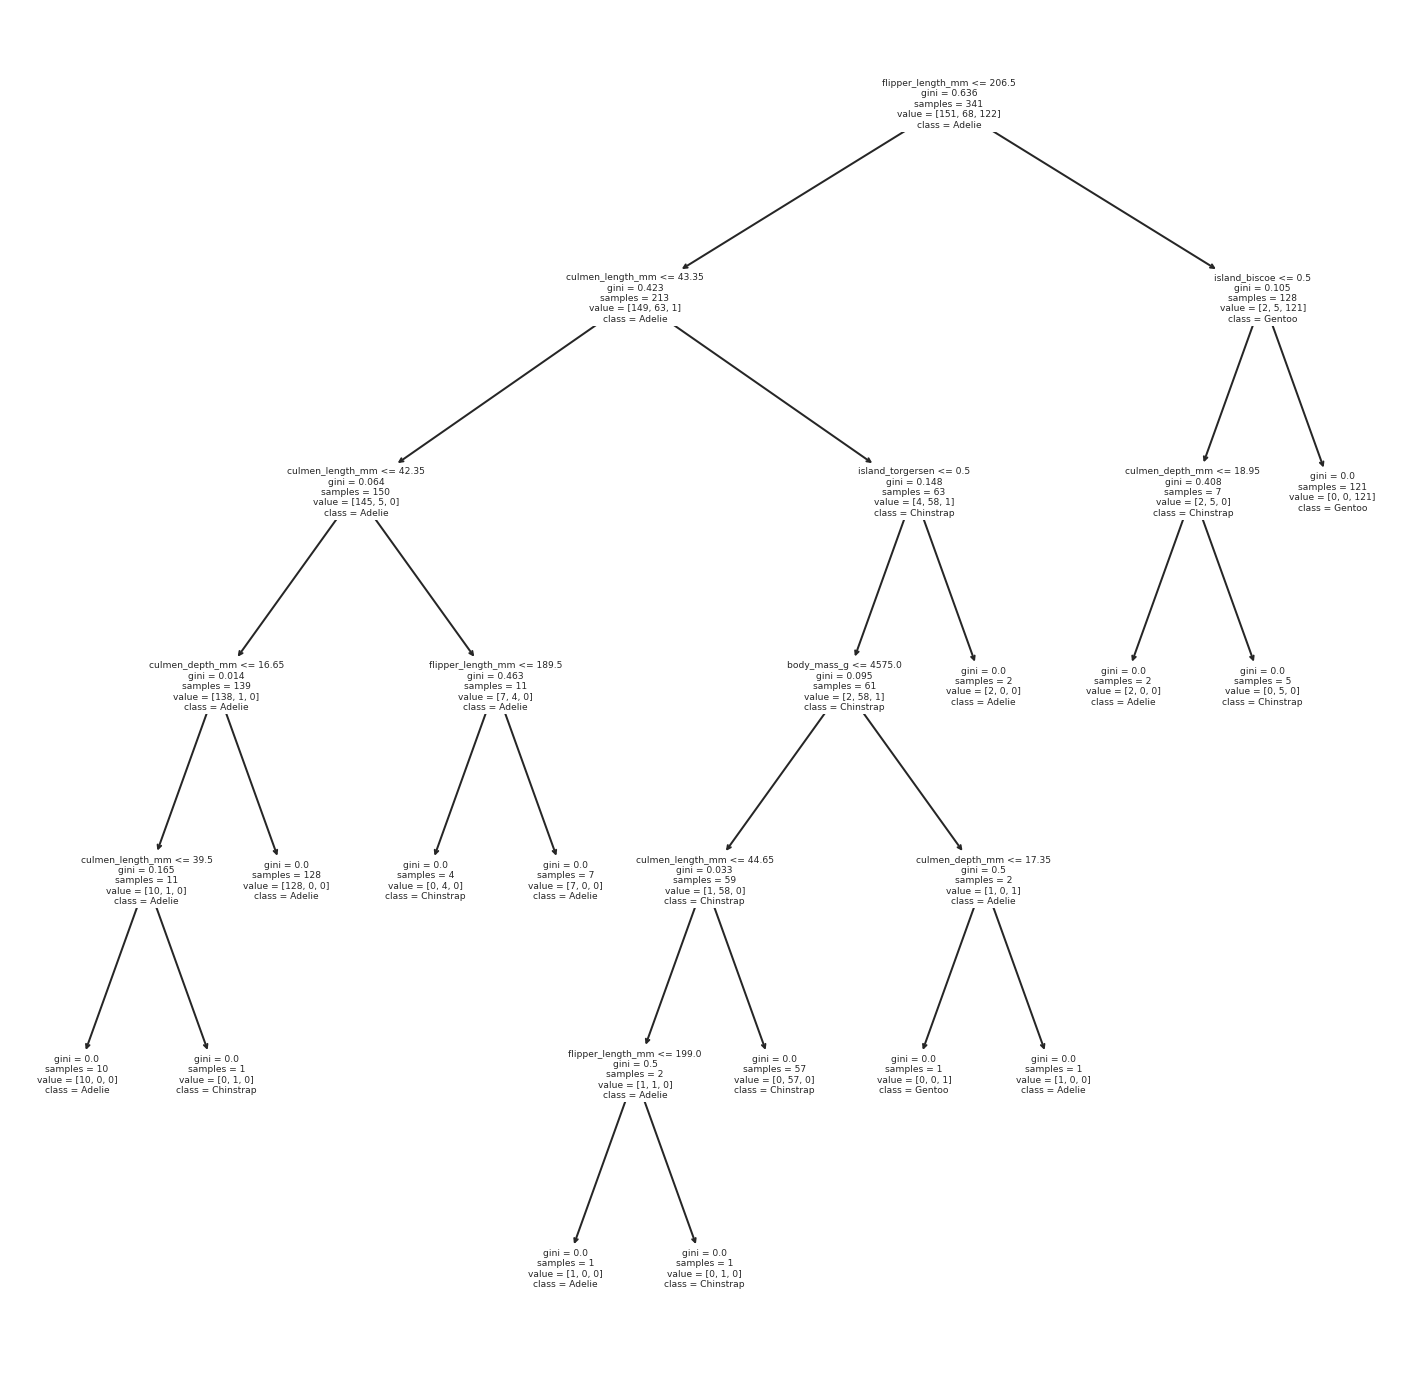

In [ ]:
# Importing DecisionTreeClassifier, and plot_tree from sklearn.tree.
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Calling the get_penguin_xy function.
X, y, feature_names, class_names = get_penguin_xy(df_penguins)

# Calling the Decision Tree Classifier model with the criterion set to gini.
DTC = DecisionTreeClassifier(criterion='gini')

# Fitting the Decision Tree Classifier model.
DTC.fit(X, y)

# Plotting the figure with a figure size of 25 X 25.
plt.figure(figsize=(25, 25))

# Calling the plot tree with the model, feature_names, and class_names passed to it.
plot_tree(DTC, feature_names=feature_names, class_names=class_names)

# Showing the plot that was created.
plt.show()

In [ ]:
# design a classification model
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

X, y, feature_names, class_names = get_penguin_xy(df_penguins)

# Using the logistic regression model to calculate the cross validation score accuracy.
model = LogisticRegression(solver='lbfgs', max_iter=10000, C=4.0)

scores = cross_val_score(model, np.array(X), np.array(y), cv=5)
print('CV Accuracy: {}'.format(scores.mean()))

CV Accuracy: 0.9970588235294118


## Part 3: Stretch Goals
Include any new code needed for Part 3 here

In [ ]:
# Creating a function called train_MLP_mnist.
def train_MLP_mnist(train_loader, val_loader, lr=0.1, num_epochs=100):
  '''
  Train a MLP 
  Input: X[i] is the ith training data. y[i] is the ith training label. alpha is the count prior
  Output: return a trained MLP
  '''
  # Declaring input_size, hidden_size, and output_size.
  input_size = 784
  hidden_size = 128
  output_size = 10

  # Instantiating the model.
  mlp = MLP(input_size, hidden_size, output_size).to(device)

  # Setting optimizer and loss function
  optimizer = torch.optim.SGD(mlp.parameters(), lr) 
  loss_function = nn.CrossEntropyLoss()

  # Creating the train_loss and val_loss arrays.
  train_loss = []
  val_loss = []

  # Training the model.
  for epoch in range(0, num_epochs):    

    # Creating the t_loss and v_loss variables.
    t_loss = 0.0
    v_loss = 0.0

    # Iterating over the DataLoader for training data.
    for i, data in enumerate(train_loader, 0): 

      inputs, targets = data # Getting inputs.

      inputs = inputs.to(device) # Sending inputs to device.

      targets = targets.to(device) # Sending targets to device.

      optimizer.zero_grad() # Zeroing the gradients.

      outputs = mlp(inputs) # Computing logit scores for current batch.

      loss = loss_function(outputs, targets) # Computing loss.

      loss.backward() # Here is the backprop loss.

      optimizer.step() # Updating weights.

      t_loss += loss.item() # Adding loss to t_loss.

    # Iterating over the DataLoader for validation data.
    for i, data in enumerate(val_loader, 0): 

      inputs, targets = data # Get inputs

      inputs = inputs.to(device) # Sending inputs to device.

      targets = targets.to(device) # Sending targets to device.

      outputs = mlp(inputs) # Computing logit scores for current batch.

      loss = loss_function(outputs, targets) # Computing loss.

      v_loss += loss.item() # Adding loss to v_loss.
 
    train_loss.append(t_loss/i) # Appending to the train_loss array.

    val_loss.append(v_loss/i) # Appending to the val_loss array.

  # Printing the loss information for the training loader.
  print("The train array is: ", train_loss)
  print("The 25 epoch is: ", train_loss[24])
  print("The 50 epoch is: ", train_loss[49])
  print("The 100 epoch is: ", train_loss[99])

  # Printing the loss information for the validation loader.
  print("The val array is: ", val_loss)
  print("The 25 epoch is: ", val_loss[24])
  print("The 50 epoch is: ", val_loss[49])
  print("The 100 epoch is: ", val_loss[99])

  # Here the loss curves are displayed.
  display_error_curves(num_epochs, train_loss, val_loss)
  
  # Here mlp is returned.
  return mlp

The train array is:  [4.364155830481113, 1.8772769558888216, 1.6030327994854023, 1.4449372108166034, 1.3285682805073566, 1.226923020222248, 1.1426446764514997, 1.0644205644344673, 0.9983757096223342, 0.9371760185712423, 0.8824917784868143, 0.8358625261447369, 0.7894948738125654, 0.7503616225260955, 0.7142025944896233, 0.681534236153731, 0.6506823375821114, 0.6217159223862183, 0.5977637049479362, 0.5745283680466505, 0.553558533008282, 0.5316918944128048, 0.5137457416798824, 0.4951299684934127, 0.48164058085053396, 0.46375614242293894, 0.4475843975177178, 0.434237088339451, 0.4211118806822178, 0.41063759294457924, 0.39764719609266674, 0.3876692008895752, 0.3756601117933408, 0.36583519593263286, 0.3550014969630119, 0.3465873300074003, 0.3376768856572035, 0.3272225260256957, 0.31982408626339376, 0.31455092552380687, 0.3053299703468115, 0.2971098883411823, 0.2903938747655887, 0.28343454925104594, 0.2760822214663793, 0.2712512128532697, 0.2641096341017729, 0.2582813325123145, 0.2522120883162

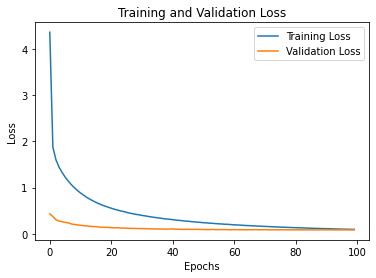

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:
# Here is the information when the hidden layer size is improved to 128.
train_MLP_mnist(train_loader, val_loader)

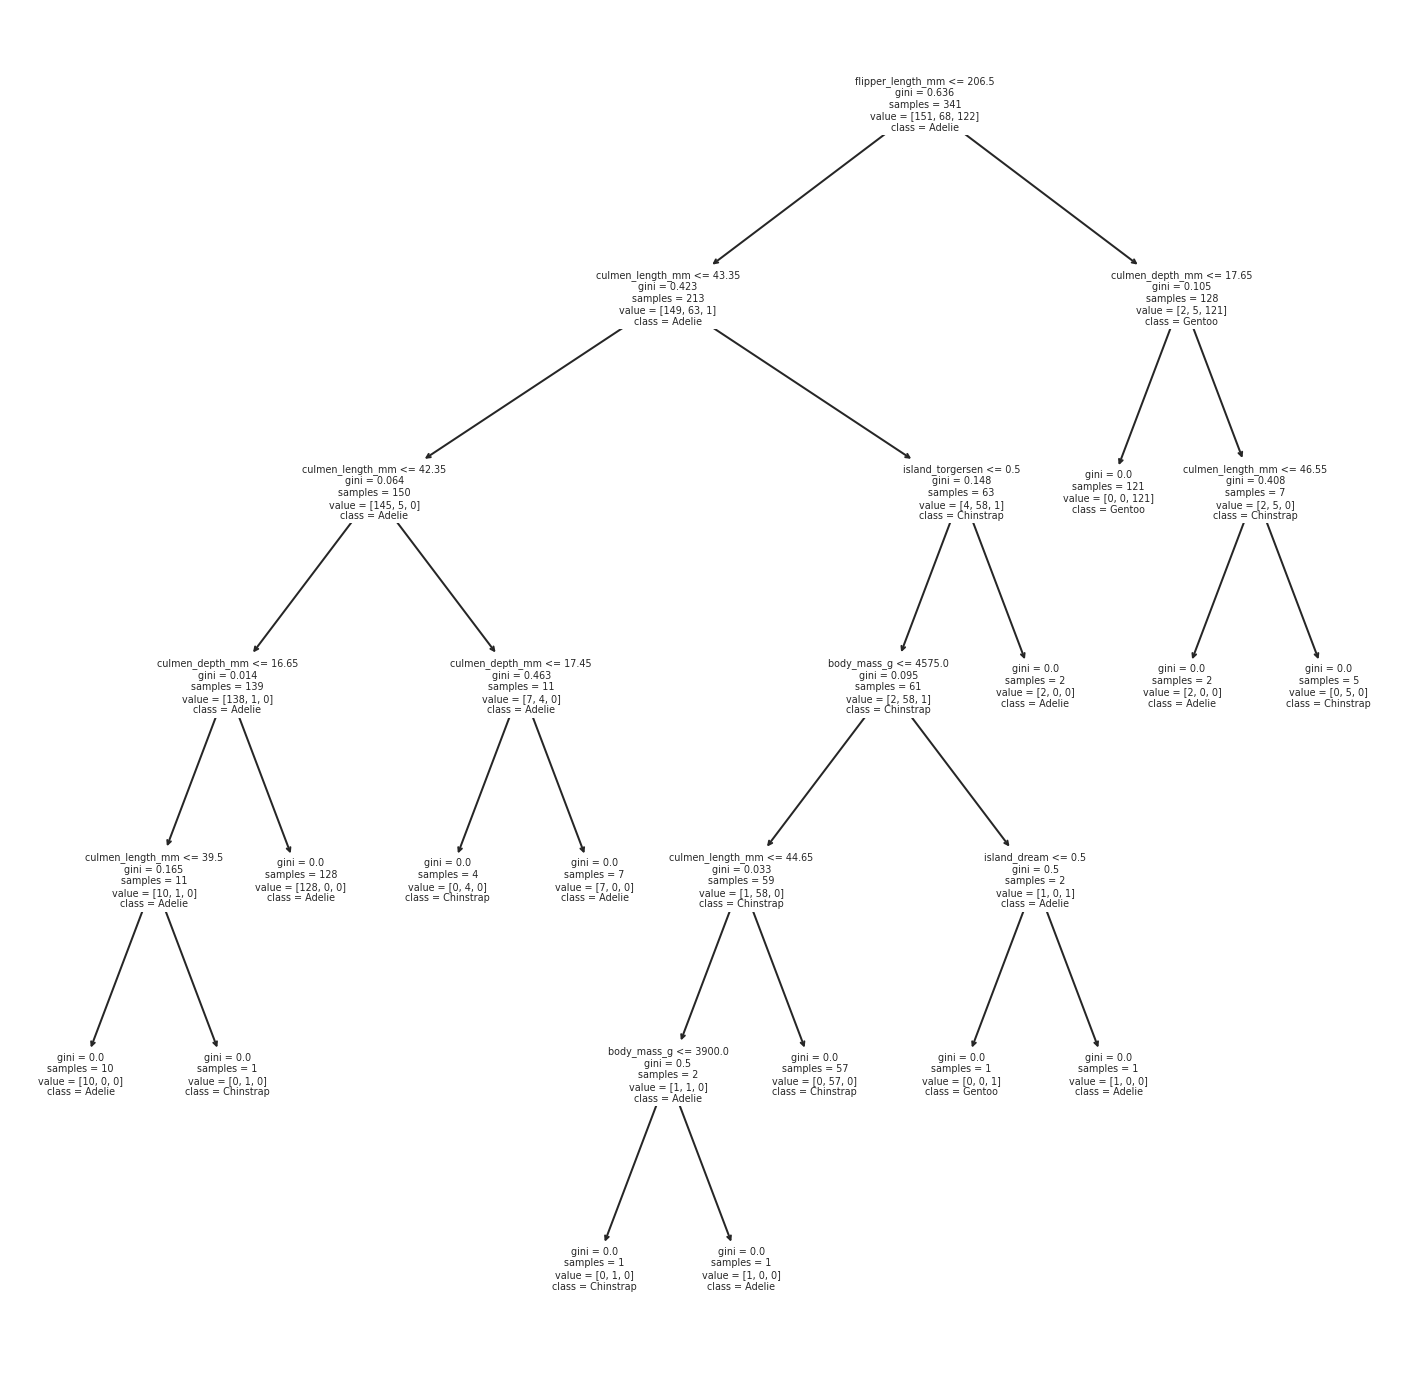

In [ ]:
# Importing DecisionTreeClassifier, and plot_tree from sklearn.tree.
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Calling the get_penguin_xy function.
X, y, feature_names, class_names = get_penguin_xy(df_penguins)

# Calling the Decision Tree Classifier model with the criterion set to gini.
DTC = DecisionTreeClassifier(criterion='gini')

# Fitting the Decision Tree Classifier model.
DTC.fit(X, y)

# Plotting the figure with a figure size of 25 X 25.
plt.figure(figsize=(25, 25))

# Calling the plot tree with the model, feature_names, and class_names passed to it.
plot_tree(DTC, feature_names=feature_names, class_names=class_names)

# Showing the plot that was created.
plt.show()

In [ ]:
# Importing the required libraries.
from google.colab import files
from PIL import Image
from numpy import array

In [ ]:
# Uploading the required image.
uploaded = files.upload()

Saving scotland_photo.jpg to scotland_photo (1).jpg


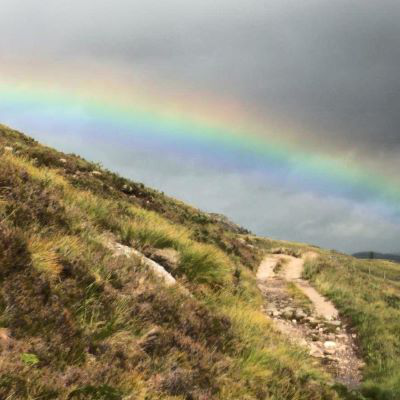

In [ ]:
# Opening the uploaded imag.
imgOne = Image.open('scotland_photo (1).jpg')
imgOne

In [ ]:
# Converting the image into an array of RGB values.
imageArray = array(imgOne)
imageArray

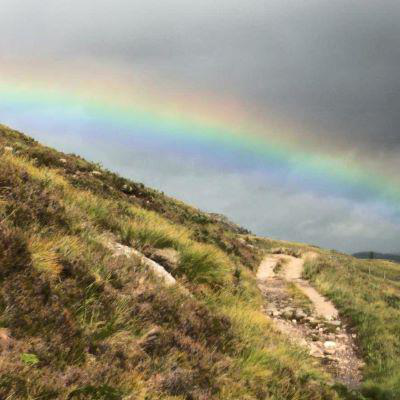

In [ ]:
# Converting the array of RGB values into a new image.
imgTwo = Image.fromarray(imageArray.astype('uint8')).convert('RGB')
imgTwo.save('newImage.jpg')
imgThree = Image.open('newImage.jpg')
imgThree